# Emotion Recognition from Speech
CNN + LSTM (PyTorch) trained on MFCC sequences to classify emotions from speech audio (RAVDESS). CodeAlpha Machine Learning Internship.

In [1]:
import os
import pickle
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from utils import (
    load_dataset_manifest, extract_sequence_from_path, generate_synthetic_dataset,
    plot_emotion_distribution, plot_waveform, plot_mfcc, plot_spectrogram, load_audio,
    N_MFCC, MAX_LEN,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('screenshots', exist_ok=True)
os.makedirs('models', exist_ok=True)


## Load Dataset (real RAVDESS if present in dataset/, else synthetic offline demo fallback)

In [2]:
manifest = load_dataset_manifest('dataset')
used_synthetic = False
if manifest.empty:
    used_synthetic = True
    X, y_raw, sample_signal, sample_sr, sample_emotion = generate_synthetic_dataset(n_per_class=40)
    dist_df = pd.DataFrame({'emotion': y_raw})
    plot_emotion_distribution(dist_df, 'screenshots/emotion_distribution.png', title='Emotion Distribution (Synthetic Demo Dataset)')
else:
    plot_emotion_distribution(manifest, 'screenshots/emotion_distribution.png')
    sample_path = manifest.iloc[0]['path']
    sample_signal, sample_sr = load_audio(sample_path)
    sequences = [extract_sequence_from_path(p) for p in manifest['path']]
    X = np.array(sequences)
    y_raw = manifest['emotion'].values

plot_waveform(sample_signal, sample_sr, 'screenshots/waveform.png')
plot_mfcc(sample_signal, sample_sr, 'screenshots/mfcc.png')
plot_spectrogram(sample_signal, sample_sr, 'screenshots/spectrogram.png')
print('used_synthetic:', used_synthetic, 'X shape:', X.shape)


c:\Users\arsla\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


used_synthetic: True X shape: (320, 130, 40)


## Encode Labels and Split

In [3]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
num_classes = len(class_names)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print('Classes:', list(class_names))
print('Train:', X_train.shape, 'Test:', X_test.shape)


Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Train: (256, 130, 40) Test: (64, 130, 40)


## Build CNN + LSTM Model

In [4]:
class EmotionCNNLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(N_MFCC, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),
            nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(0.3),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128),
            nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(0.3),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.4)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (batch, MAX_LEN, N_MFCC) -> (batch, N_MFCC, MAX_LEN) for Conv1d
        x = x.transpose(1, 2)
        x = self.conv_block(x)
        # (batch, channels, seq_len) -> (batch, seq_len, channels) for LSTM
        x = x.transpose(1, 2)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]
        x = self.lstm_dropout(x)
        x = self.head(x)
        return x  # raw logits; use nn.CrossEntropyLoss / torch.softmax

model = EmotionCNNLSTM(num_classes).to(DEVICE)
print(model)


EmotionCNNLSTM(
  (conv_block): Sequential(
    (0): Conv1d(40, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(128, 128, batch_first=True)
  (lstm_dropout): Dropout(p=0.4, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=8, bias=True)
  )
)


## Train

In [5]:
X_train_t = torch.from_numpy(X_train.astype('float32'))
y_train_t = torch.from_numpy(y_train.astype('int64'))
X_test_t = torch.from_numpy(X_test.astype('float32'))
y_test_t = torch.from_numpy(y_test.astype('int64'))

full_train_ds = TensorDataset(X_train_t, y_train_t)
val_size = int(0.15 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(RANDOM_SEED))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs, patience = 60, 8
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
best_val_loss, best_state, epochs_without_improvement = float('inf'), None, 0

for epoch in range(epochs):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        running_correct += (outputs.argmax(1) == yb).sum().item()
        running_total += xb.size(0)
    train_loss, train_acc = running_loss / running_total, running_correct / running_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (outputs.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total

    history['loss'].append(train_loss); history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)
    print(f'Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} '
          f'- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss, best_state, epochs_without_improvement = val_loss, copy.deepcopy(model.state_dict()), 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f'Early stopping at epoch {epoch+1} (best val_loss: {best_val_loss:.4f})')
            break

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 1/60 - loss: 1.9828 - accuracy: 0.2248 - val_loss: 1.8344 - val_accuracy: 0.4211
Epoch 2/60 - loss: 1.6683 - accuracy: 0.3211 - val_loss: 1.3803 - val_accuracy: 0.6842
Epoch 3/60 - loss: 1.3158 - accuracy: 0.4266 - val_loss: 1.0645 - val_accuracy: 0.6316
Epoch 4/60 - loss: 1.0748 - accuracy: 0.5046 - val_loss: 0.7992 - val_accuracy: 0.6842
Epoch 5/60 - loss: 0.8982 - accuracy: 0.5688 - val_loss: 0.7041 - val_accuracy: 0.6842
Epoch 6/60 - loss: 0.9350 - accuracy: 0.5046 - val_loss: 0.7218 - val_accuracy: 0.5789
Epoch 7/60 - loss: 0.8062 - accuracy: 0.6560 - val_loss: 0.6529 - val_accuracy: 0.6579
Epoch 8/60 - loss: 0.7008 - accuracy: 0.6881 - val_loss: 0.5378 - val_accuracy: 0.9737
Epoch 9/60 - loss: 0.5703 - accuracy: 0.8028 - val_loss: 0.5134 - val_accuracy: 0.7368
Epoch 10/60 - loss: 0.6261 - accuracy: 0.7064 - val_loss: 0.4865 - val_accuracy: 0.9211
Epoch 11/60 - loss: 0.7648 - accuracy: 0.6927 - val_loss: 0.5570 - val_accuracy: 0.7632
Epoch 12/60 - loss: 0.5779 - accuracy: 0.

## Training History

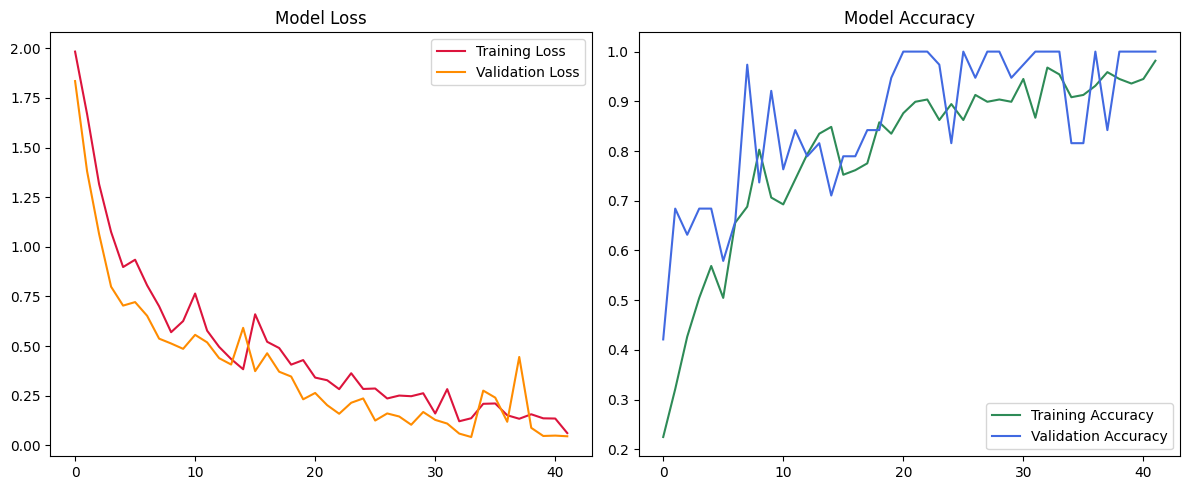

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history['loss'], label='Training Loss', color='crimson')
axes[0].plot(history['val_loss'], label='Validation Loss', color='darkorange')
axes[0].set_title('Model Loss'); axes[0].legend()
axes[1].plot(history['accuracy'], label='Training Accuracy', color='seagreen')
axes[1].plot(history['val_accuracy'], label='Validation Accuracy', color='royalblue')
axes[1].set_title('Model Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('screenshots/training_history.png', dpi=150)
plt.show()


## Evaluate on Test Set

In [7]:
model.eval()
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)
all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        all_preds.append(outputs.argmax(1).cpu().numpy())
y_pred = np.concatenate(all_preds)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}')
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)
with open('screenshots/classification_report.txt', 'w') as f:
    f.write(f'Test Accuracy: {test_acc:.4f}\n\n')
    f.write(report)
    if used_synthetic:
        f.write('\n\nNOTE: This run used an in-memory SYNTHETIC demo dataset.\n')


Test Accuracy: 1.0000
              precision    recall  f1-score   support

       angry     1.0000    1.0000    1.0000         8
        calm     1.0000    1.0000    1.0000         8
     disgust     1.0000    1.0000    1.0000         8
     fearful     1.0000    1.0000    1.0000         8
       happy     1.0000    1.0000    1.0000         8
     neutral     1.0000    1.0000    1.0000         8
         sad     1.0000    1.0000    1.0000         8
   surprised     1.0000    1.0000    1.0000         8

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



## Confusion Matrix

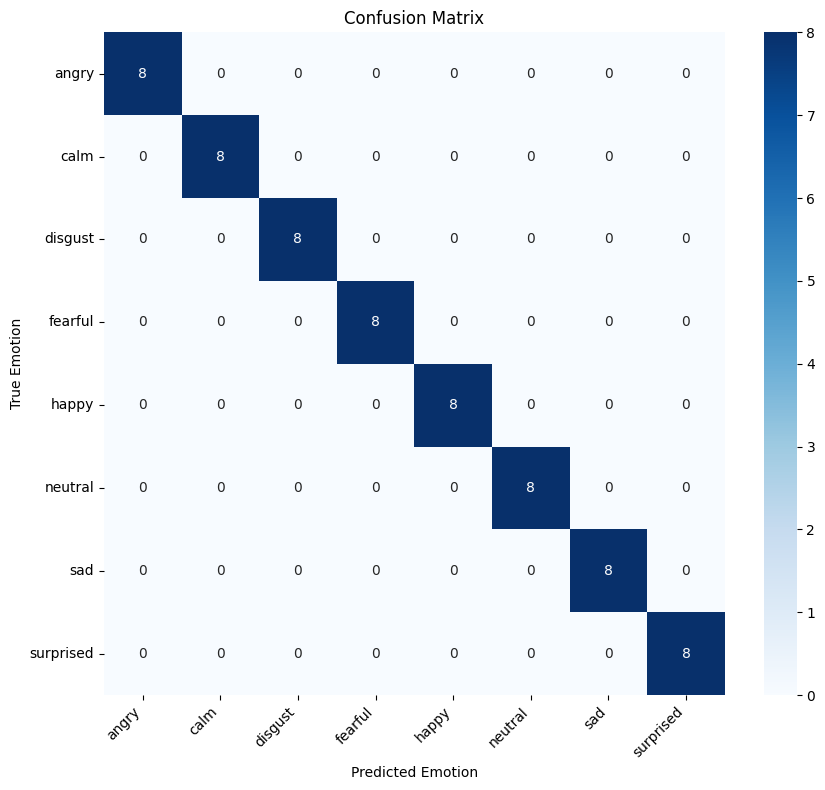

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted Emotion'); plt.ylabel('True Emotion')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('screenshots/confusion_matrix.png', dpi=150)
plt.show()


## Save Model

In [9]:
torch.save({'model_state_dict': model.state_dict(), 'num_classes': num_classes}, 'models/emotion_cnn_lstm.pt')
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print('Saved model and label encoder.')


Saved model and label encoder.
